# Second try 

In [2]:
!pip3 install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.8 MB/s eta 0:00:00a 0:00:01


In [4]:
import shutil

shutil.copy(
    "/kaggle/input/datasets/ashishkumar129/modified/data.yaml",
    "/kaggle/working/data.yaml"
)

'/kaggle/working/data.yaml'

In [5]:
yaml_content = """
train: /kaggle/input/datasets/ashishkumar129/modified/unified_dataset (1)/content/unified_dataset/train/images
val: /kaggle/input/datasets/ashishkumar129/modified/unified_dataset (1)/content/unified_dataset/val/images

nc: 4

names:
  - knife
  - handgun
  - rifle
  - launcher
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml updated successfully")

data.yaml updated successfully


In [6]:
with open("/kaggle/working/data.yaml") as f:
    print(f.read())


train: /kaggle/input/datasets/ashishkumar129/modified/unified_dataset (1)/content/unified_dataset/train/images
val: /kaggle/input/datasets/ashishkumar129/modified/unified_dataset (1)/content/unified_dataset/val/images

nc: 4

names:
  - knife
  - handgun
  - rifle
  - launcher



In [3]:
from ultralytics import YOLO
import torch

# Check for GPU availability
if torch.backends.mps.is_available():
    device = "mps"     # Apple Silicon GPU
elif torch.cuda.is_available():
    device = "cuda"    # NVIDIA GPU
else:
    device = "cpu"     # CPU fallback

print(f"Using device: {device}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cuda


In [7]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))
print("GPU Count:", torch.cuda.device_count())

CUDA Available: True
GPU Name: Tesla T4
GPU Count: 2


In [8]:
from ultralytics import YOLO
import torch

# Check for GPU availability
if torch.backends.mps.is_available():
    device = "mps"     # Apple Silicon GPU
elif torch.cuda.is_available():
    device = "cuda"    # NVIDIA GPU
else:
    device = "cpu"     # CPU fallback

print(f"Using device: {device}")

# 1. Load a pretrained YOLOv8 model
model = YOLO('yolov8n.pt')

# 2. Train the model with Early Stopping
print("\n--- Starting YOLOv8 Model Training ---")

results = model.train(
    data='/kaggle/working/data.yaml',
    epochs=120,
    imgsz=640,
    batch=16,
    device=device, # Dynamically set device based on availability
    patience=20,    # EARLY STOPPING (stop if no improvement for 20 epochs)
    project='yolov8_weapon_detection',
    name='unified_dataset_training',
    exist_ok=True
)

# 3. Print training metrics
print("\n--- Training Metrics ---")

# Ultralytics results object stores metrics in a specific format
# We need to load the metrics from the `trainer.metrics` attribute after training
# Or, if not directly accessible, parse from the results object or log files.
# For simplicity, if `results.metrics` is available, use it.

if results.metrics is not None:
    # Assuming metrics are directly available after training in `results.metrics`
    # Note: 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)'
    # are typically found in the validation metrics (e.g., results.val.metrics) or in the logs.
    # The exact key names might vary slightly based on Ultralytics version or if a full `val` run is performed.
    # If results.metrics is a dict, we can access it directly.
    # If it's an object, we'll try common attribute names.
    
    # Try accessing common metric names directly or through attributes
    precision = results.metrics.get('metrics/precision(B)') if isinstance(results.metrics, dict) else getattr(results.metrics, 'mp', 'N/A')
    recall = results.metrics.get('metrics/recall(B)') if isinstance(results.metrics, dict) else getattr(results.metrics, 'mr', 'N/A')
    mAP50 = results.metrics.get('metrics/mAP50(B)') if isinstance(results.metrics, dict) else getattr(results.metrics, 'map50', 'N/A')
    mAP50_95 = results.metrics.get('metrics/mAP50-95(B)') if isinstance(results.metrics, dict) else getattr(results.metrics, 'map50-95', 'N/A')

    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"mAP50: {mAP50}")
    print(f"mAP50-95: {mAP50_95}")
else:
    print("Training metrics not available. Check training logs in 'yolov8_weapon_detection/unified_dataset_training' directory.")

print("YOLOv8 model training complete.")

Using device: cuda

--- Starting YOLOv8 Model Training ---
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=unified_dataset_training, nbs=64, nms=False, opset=None, optimi

AttributeError: 'DetMetrics' object has no attribute 'metrics'. See valid attributes below.
Utility class for computing detection metrics such as precision, recall, and mean average precision (mAP).

    Attributes:
        names (dict[int, str]): A dictionary of class names.
        box (Metric): An instance of the Metric class for storing detection results.
        speed (dict[str, float]): A dictionary for storing execution times of different parts of the detection process.
        task (str): The task type, set to 'detect'.
        stats (dict[str, list]): A dictionary containing lists for true positives, confidence scores, predicted classes,
            target classes, and target images.
        nt_per_class: Number of targets per class.
        nt_per_image: Number of targets per image.

    Methods:
        update_stats: Update statistics by appending new values to existing stat collections.
        process: Process predicted results for object detection and update metrics.
    

In [12]:
print("\n--- Training Metrics ---")

try:
    metrics = results.results_dict

    precision = metrics.get('metrics/precision(B)', 'N/A')
    recall = metrics.get('metrics/recall(B)', 'N/A')
    mAP50 = metrics.get('metrics/mAP50(B)', 'N/A')
    mAP50_95 = metrics.get('metrics/mAP50-95(B)', 'N/A')

    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"mAP50: {mAP50}")
    print(f"mAP50-95: {mAP50_95}")

except Exception as e:
    print("Metrics not available:", e)


--- Training Metrics ---
Precision: 0.8340564651094686
Recall: 0.7844307896358473
mAP50: 0.8348156544700222
mAP50-95: 0.6641602038988884


In [16]:
import shutil
import os

source = "/kaggle/working/runs/detect/yolov8_weapon_detection/unified_dataset_training/weights/best.pt"
destination = "/kaggle/working/best.pt"

if os.path.exists(source):
    shutil.copy(source, destination)
    print("Model copied successfully!")
    print("Saved at:", destination)
else:
    print("best.pt not found")

Model copied successfully!
Saved at: /kaggle/working/best.pt


In [17]:
from ultralytics import YOLO

# Load trained model
model = YOLO("/kaggle/working/runs/detect/yolov8_weapon_detection/unified_dataset_training/weights/best.pt")

# Run validation on the dataset
metrics = model.val(data="/kaggle/working/data.yaml")

print("\n--- Accuracy Metrics ---")
print(metrics.results_dict)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 63.6±89.7 MB/s, size: 75.0 KB)
val: Scanning /kaggle/input/datasets/ashishkumar129/modified/unified_dataset (1)/content/unified_dataset/val/labels... 419 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 419/419 766.8it/s 0.5s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ashishkumar129/modified/unified_dataset (1)/content/unified_dataset/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 6.3it/s 4.3s0.1s
                   all        419        529      0.836      0.784      0.834       0.66
                 knife        198        210      0.915       0.71       0.85      0.546
               handgun         82        106      0.593      0.623      0.621      0.


--- Important Training Graphs ---


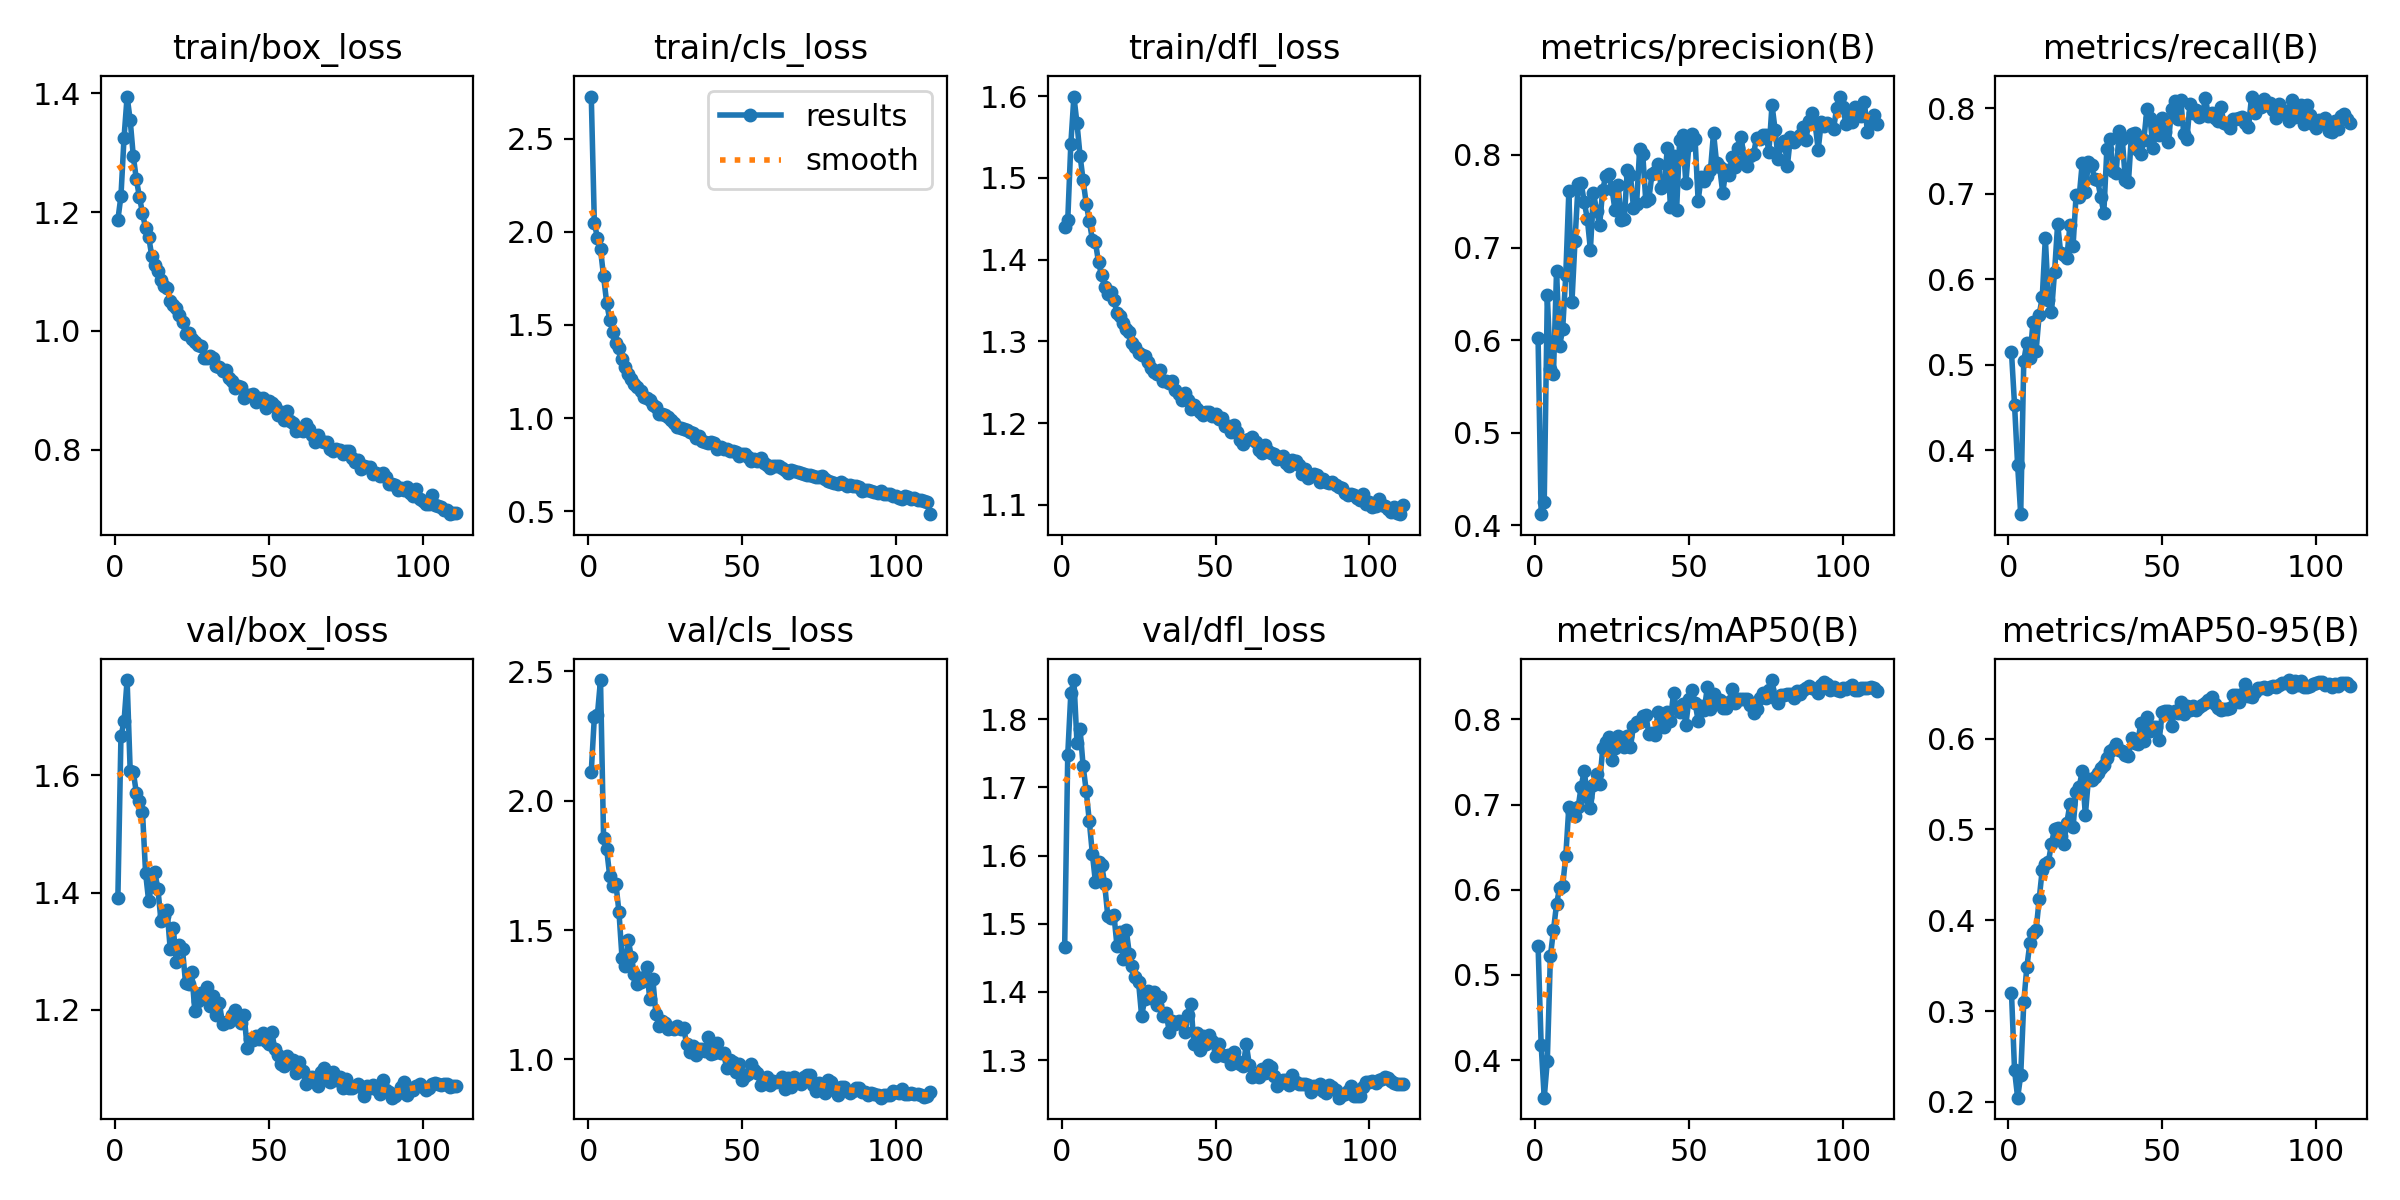

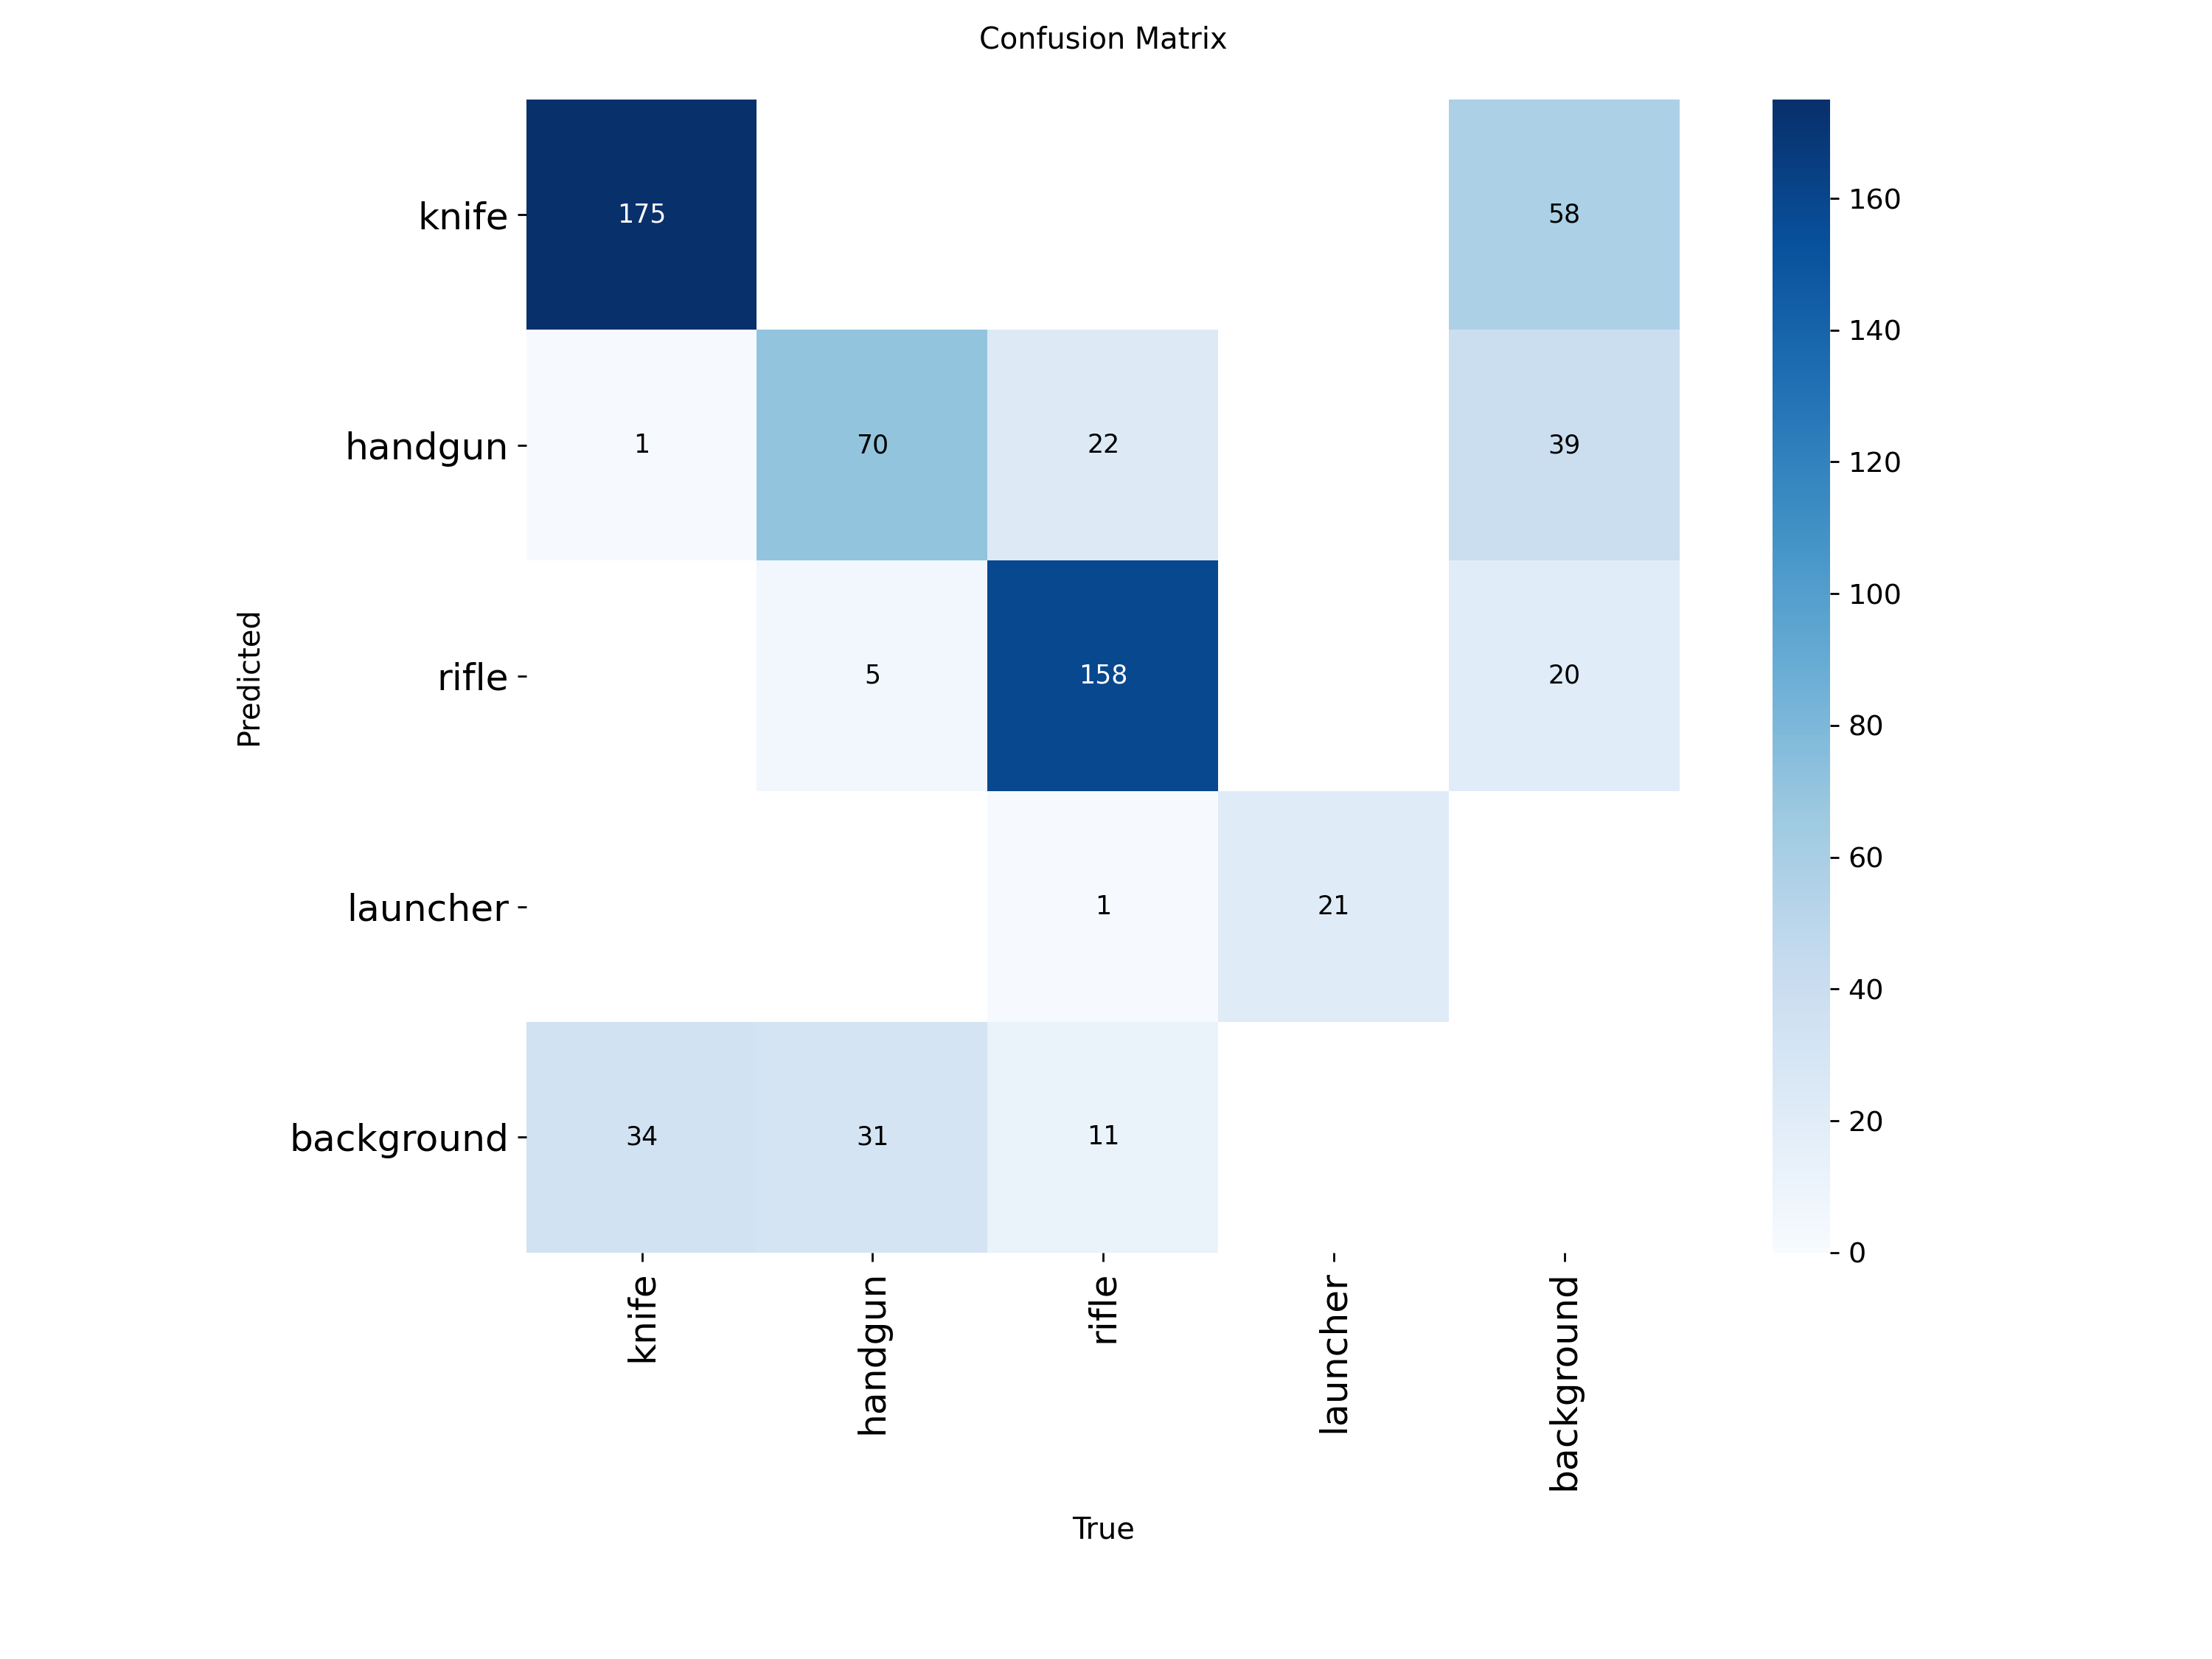

PR_curve.png not found
F1_curve.png not found
P_curve.png not found
R_curve.png not found


In [18]:
from IPython.display import Image, display
import os

results_dir = "/kaggle/working/runs/detect/yolov8_weapon_detection/unified_dataset_training"

plots = [
    "results.png",
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png"
]

print("\n--- Important Training Graphs ---")

for plot in plots:
    path = os.path.join(results_dir, plot)
    if os.path.exists(path):
        display(Image(filename=path))
    else:
        print(f"{plot} not found")

In [19]:
import pandas as pd

metrics_dict = metrics.results_dict

data = {
    "Metric": ["Precision", "Recall", "mAP@50", "mAP@50-95"],
    "Value": [
        metrics_dict['metrics/precision(B)'],
        metrics_dict['metrics/recall(B)'],
        metrics_dict['metrics/mAP50(B)'],
        metrics_dict['metrics/mAP50-95(B)']
    ]
}

df = pd.DataFrame(data)
df

,Metric,Value
0,Precision,0.836084
1,Recall,0.783562
2,mAP@50,0.834484
3,mAP@50-95,0.660436


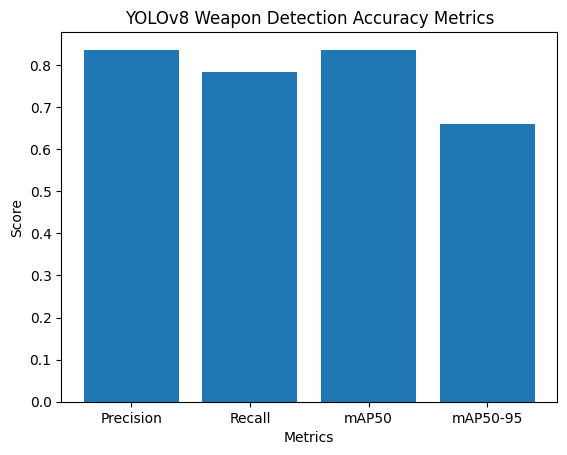

In [20]:
import matplotlib.pyplot as plt

values = [
    metrics_dict['metrics/precision(B)'],
    metrics_dict['metrics/recall(B)'],
    metrics_dict['metrics/mAP50(B)'],
    metrics_dict['metrics/mAP50-95(B)']
]

labels = ["Precision", "Recall", "mAP50", "mAP50-95"]

plt.figure()
plt.bar(labels, values)
plt.title("YOLOv8 Weapon Detection Accuracy Metrics")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.show()